<a href="https://colab.research.google.com/github/DikshyaL/DL-practical-lab/blob/main/COMP488P3_Dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Regularization & Optimization in Neural Networks

**Course:** COMP 488 - Neural Network and Deep Learning  
**Student Name:** Dikshya Lamichhane  
**Date:** April 18, 2026  
**Dataset:** Fashion-MNIST (OpenML)  
**Tools Used:** NumPy, scikit-learn, Matplotlib, PyTorch


## Objective

- To study how regularization and optimizer choices affect neural network generalization.
- To compare a baseline MLP with L1 regularization, L2 regularization, dropout, and batch normalization.
- To demonstrate overfitting using training and validation loss curves.
- To analyze the trade-offs between training performance and validation performance.
- To identify which technique improves generalization the most on Fashion-MNIST.

## Theoretical Background

Regularization is used to reduce overfitting by limiting model complexity or discouraging overly large weights. In neural networks, common regularization methods include L1 regularization, L2 regularization, dropout, and batch normalization.

### L1 Regularization
L1 adds a penalty proportional to the absolute value of weights:

\[
L = L_{data} + \lambda \sum |w|
\]

It encourages sparsity, meaning some weights may become very small or zero.

### L2 Regularization
L2 adds a penalty proportional to the squared magnitude of weights:

\[
L = L_{data} + \lambda \sum w^2
\]

It discourages large weights and often improves stability.

### Dropout
Dropout randomly disables some neurons during training. This prevents neurons from relying too heavily on each other and improves generalization.

### Batch Normalization
Batch normalization normalizes intermediate activations during training. It helps stabilize and speed up training by reducing internal covariate shift.

### Optimizers
- **SGD** updates parameters using gradients and is simple but can be slower.
- **Adam** adapts learning rates for each parameter and often converges faster.

### Overfitting
Overfitting happens when training performance improves while validation performance stops improving or gets worse. This is visible when the train loss keeps decreasing but validation loss starts to flatten or rise.
## Dataset Description

The dataset used is Fashion-MNIST, an image classification dataset with 10 classes of clothing items.

- Source: OpenML / Fashion-MNIST benchmark
- Number of samples: 70,000 total
- Training samples: 60,000
- Test samples: 10,000
- Image size: 28 x 28 grayscale
- Number of features: 784 pixels per image after flattening
- Classes:
  0. T-shirt/top
  1. Trouser
  2. Pullover
  3. Dress
  4. Coat
  5. Sandal
  6. Shirt
  7. Sneaker
  8. Bag
  9. Ankle boot

For this lab, the training set is split into training and validation subsets so that model generalization can be measured during training.


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [15]:
# Dataset loading
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = 50000
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = train_full.classes
print("Classes:", classes)

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [16]:
# Model definition
class MLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False):
        super().__init__()
        layers = []

        layers.append(nn.Linear(28 * 28, 512))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(512))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(0.3))

        layers.append(nn.Linear(512, 256))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(0.3))

        layers.append(nn.Linear(256, 128))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(0.3))

        layers.append(nn.Linear(128, 10))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [17]:
def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def train_one_epoch(model, loader, criterion, optimizer, l1_lambda=0.0):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        if l1_lambda > 0:
            l1_penalty = 0.0
            for param in model.parameters():
                l1_penalty += param.abs().sum()
            loss = loss + l1_lambda * l1_penalty

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    avg_loss = running_loss / len(loader.dataset)
    acc = correct / total
    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)

        running_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    avg_loss = running_loss / len(loader.dataset)
    acc = correct / total
    return avg_loss, acc


def run_experiment(name, model, train_loader, val_loader, criterion, optimizer, epochs=10, l1_lambda=0.0):
    model = model.to(device)
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, l1_lambda=l1_lambda
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"{name} | Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    plot_losses(train_losses, val_losses, name)
    return model, train_losses, val_losses, train_accs, val_accs


### Experiment 1: Baseline Overfitting Model

Experiment 1: Baseline Overfitting Model | Epoch 1/20 | Train Loss: 0.8077, Train Acc: 0.7140 | Val Loss: 0.4990, Val Acc: 0.8213
Experiment 1: Baseline Overfitting Model | Epoch 2/20 | Train Loss: 0.4382, Train Acc: 0.8412 | Val Loss: 0.4223, Val Acc: 0.8481
Experiment 1: Baseline Overfitting Model | Epoch 3/20 | Train Loss: 0.3892, Train Acc: 0.8569 | Val Loss: 0.3774, Val Acc: 0.8671
Experiment 1: Baseline Overfitting Model | Epoch 4/20 | Train Loss: 0.3518, Train Acc: 0.8730 | Val Loss: 0.3570, Val Acc: 0.8703
Experiment 1: Baseline Overfitting Model | Epoch 5/20 | Train Loss: 0.3319, Train Acc: 0.8785 | Val Loss: 0.3434, Val Acc: 0.8758
Experiment 1: Baseline Overfitting Model | Epoch 6/20 | Train Loss: 0.3146, Train Acc: 0.8835 | Val Loss: 0.3351, Val Acc: 0.8774
Experiment 1: Baseline Overfitting Model | Epoch 7/20 | Train Loss: 0.2997, Train Acc: 0.8894 | Val Loss: 0.3234, Val Acc: 0.8820
Experiment 1: Baseline Overfitting Model | Epoch 8/20 | Train Loss: 0.2868, Train Acc: 0.8

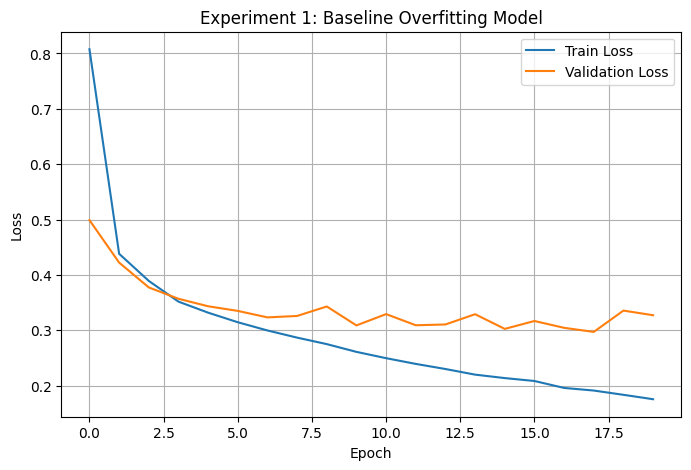

In [18]:
# Experiment 1: no regularization
baseline_model = MLP(use_dropout=False, use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(baseline_model.parameters(), lr=0.01, momentum=0.9)

baseline_model, baseline_train_losses, baseline_val_losses, baseline_train_accs, baseline_val_accs = run_experiment(
    "Experiment 1: Baseline Overfitting Model",
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20
)

### Experiment 2: L1 regularization

Experiment 2: L1 Regularization | Epoch 1/12 | Train Loss: 0.9158, Train Acc: 0.7096 | Val Loss: 0.5047, Val Acc: 0.8155
Experiment 2: L1 Regularization | Epoch 2/12 | Train Loss: 0.5548, Train Acc: 0.8394 | Val Loss: 0.4261, Val Acc: 0.8450
Experiment 2: L1 Regularization | Epoch 3/12 | Train Loss: 0.5035, Train Acc: 0.8558 | Val Loss: 0.4046, Val Acc: 0.8512
Experiment 2: L1 Regularization | Epoch 4/12 | Train Loss: 0.4706, Train Acc: 0.8701 | Val Loss: 0.3587, Val Acc: 0.8690
Experiment 2: L1 Regularization | Epoch 5/12 | Train Loss: 0.4501, Train Acc: 0.8754 | Val Loss: 0.3571, Val Acc: 0.8693
Experiment 2: L1 Regularization | Epoch 6/12 | Train Loss: 0.4292, Train Acc: 0.8828 | Val Loss: 0.3621, Val Acc: 0.8678
Experiment 2: L1 Regularization | Epoch 7/12 | Train Loss: 0.4108, Train Acc: 0.8885 | Val Loss: 0.3347, Val Acc: 0.8803
Experiment 2: L1 Regularization | Epoch 8/12 | Train Loss: 0.3972, Train Acc: 0.8924 | Val Loss: 0.3378, Val Acc: 0.8768
Experiment 2: L1 Regularization 

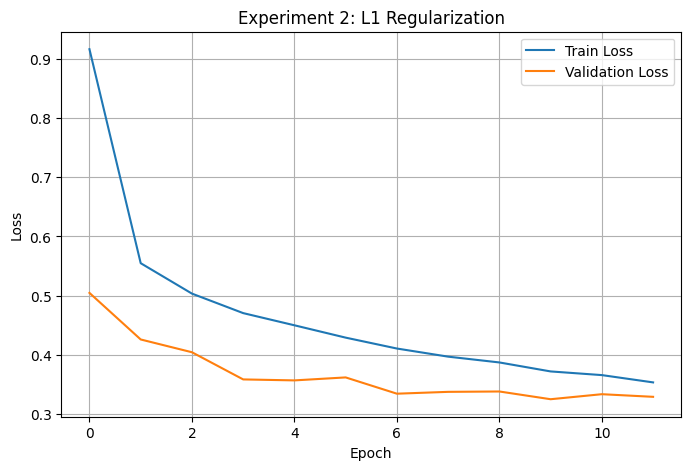

In [19]:
# Experiment 2: L1 regularization
l1_model = MLP(use_dropout=False, use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(l1_model.parameters(), lr=0.01, momentum=0.9)

l1_lambda = 1e-5

l1_model, l1_train_losses, l1_val_losses, l1_train_accs, l1_val_accs = run_experiment(
    "Experiment 2: L1 Regularization",
    l1_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=12,
    l1_lambda=l1_lambda
)

### Experiment 3: L2 Regularization

Experiment 3: L2 Regularization | Epoch 1/12 | Train Loss: 0.8123, Train Acc: 0.7213 | Val Loss: 0.4879, Val Acc: 0.8264
Experiment 3: L2 Regularization | Epoch 2/12 | Train Loss: 0.4419, Train Acc: 0.8397 | Val Loss: 0.4509, Val Acc: 0.8347
Experiment 3: L2 Regularization | Epoch 3/12 | Train Loss: 0.3910, Train Acc: 0.8563 | Val Loss: 0.3785, Val Acc: 0.8635
Experiment 3: L2 Regularization | Epoch 4/12 | Train Loss: 0.3571, Train Acc: 0.8686 | Val Loss: 0.3929, Val Acc: 0.8559
Experiment 3: L2 Regularization | Epoch 5/12 | Train Loss: 0.3328, Train Acc: 0.8775 | Val Loss: 0.3530, Val Acc: 0.8734
Experiment 3: L2 Regularization | Epoch 6/12 | Train Loss: 0.3112, Train Acc: 0.8849 | Val Loss: 0.3403, Val Acc: 0.8752
Experiment 3: L2 Regularization | Epoch 7/12 | Train Loss: 0.2979, Train Acc: 0.8894 | Val Loss: 0.3478, Val Acc: 0.8749
Experiment 3: L2 Regularization | Epoch 8/12 | Train Loss: 0.2848, Train Acc: 0.8949 | Val Loss: 0.3209, Val Acc: 0.8855
Experiment 3: L2 Regularization 

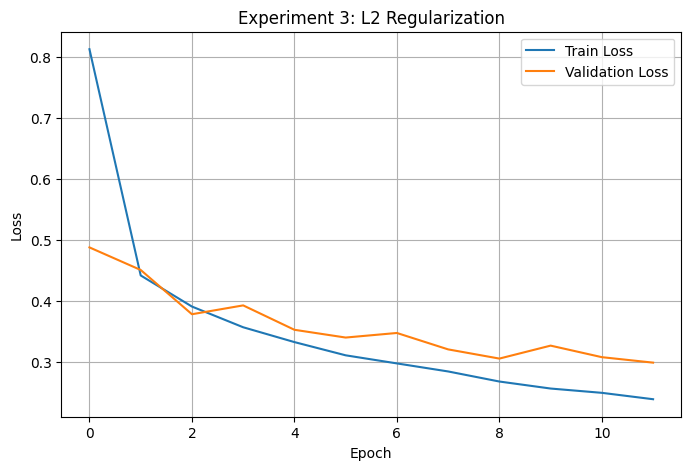

In [20]:
# Experiment 3: L2 Regularization
l2_model = MLP(use_dropout=False, use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(l2_model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

l2_model, l2_train_losses, l2_val_losses, l2_train_accs, l2_val_accs = run_experiment(
    "Experiment 3: L2 Regularization",
    l2_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=12
)

### Experiment 4: Dropout with Adam

Experiment 4: Dropout + Adam | Epoch 1/12 | Train Loss: 0.6369, Train Acc: 0.7684 | Val Loss: 0.4369, Val Acc: 0.8444
Experiment 4: Dropout + Adam | Epoch 2/12 | Train Loss: 0.4505, Train Acc: 0.8395 | Val Loss: 0.3973, Val Acc: 0.8562
Experiment 4: Dropout + Adam | Epoch 3/12 | Train Loss: 0.4087, Train Acc: 0.8518 | Val Loss: 0.3687, Val Acc: 0.8636
Experiment 4: Dropout + Adam | Epoch 4/12 | Train Loss: 0.3857, Train Acc: 0.8612 | Val Loss: 0.3590, Val Acc: 0.8703
Experiment 4: Dropout + Adam | Epoch 5/12 | Train Loss: 0.3689, Train Acc: 0.8662 | Val Loss: 0.3503, Val Acc: 0.8737
Experiment 4: Dropout + Adam | Epoch 6/12 | Train Loss: 0.3526, Train Acc: 0.8723 | Val Loss: 0.3543, Val Acc: 0.8737
Experiment 4: Dropout + Adam | Epoch 7/12 | Train Loss: 0.3385, Train Acc: 0.8780 | Val Loss: 0.3404, Val Acc: 0.8791
Experiment 4: Dropout + Adam | Epoch 8/12 | Train Loss: 0.3292, Train Acc: 0.8800 | Val Loss: 0.3276, Val Acc: 0.8815
Experiment 4: Dropout + Adam | Epoch 9/12 | Train Loss: 

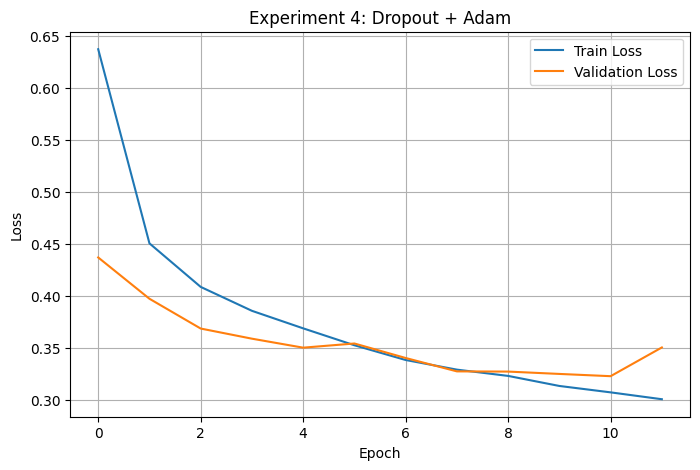

In [21]:
# Dropout with Adam
dropout_model = MLP(use_dropout=True, use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=0.001)

dropout_model, dropout_train_losses, dropout_val_losses, dropout_train_accs, dropout_val_accs = run_experiment(
    "Experiment 4: Dropout + Adam",
    dropout_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=12
)

### Experiment 5: Batch Normalization with Adam

Experiment 5: BatchNorm + Adam | Epoch 1/12 | Train Loss: 0.4608, Train Acc: 0.8398 | Val Loss: 0.3896, Val Acc: 0.8624
Experiment 5: BatchNorm + Adam | Epoch 2/12 | Train Loss: 0.3332, Train Acc: 0.8780 | Val Loss: 0.3468, Val Acc: 0.8728
Experiment 5: BatchNorm + Adam | Epoch 3/12 | Train Loss: 0.2920, Train Acc: 0.8917 | Val Loss: 0.3100, Val Acc: 0.8877
Experiment 5: BatchNorm + Adam | Epoch 4/12 | Train Loss: 0.2678, Train Acc: 0.9014 | Val Loss: 0.3281, Val Acc: 0.8817
Experiment 5: BatchNorm + Adam | Epoch 5/12 | Train Loss: 0.2454, Train Acc: 0.9088 | Val Loss: 0.3026, Val Acc: 0.8910
Experiment 5: BatchNorm + Adam | Epoch 6/12 | Train Loss: 0.2268, Train Acc: 0.9145 | Val Loss: 0.3017, Val Acc: 0.8906
Experiment 5: BatchNorm + Adam | Epoch 7/12 | Train Loss: 0.2097, Train Acc: 0.9212 | Val Loss: 0.3034, Val Acc: 0.8933
Experiment 5: BatchNorm + Adam | Epoch 8/12 | Train Loss: 0.1997, Train Acc: 0.9251 | Val Loss: 0.3141, Val Acc: 0.8890
Experiment 5: BatchNorm + Adam | Epoch 9

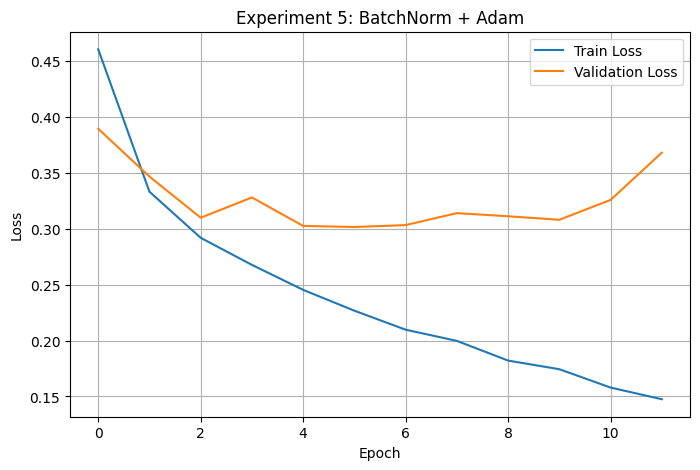

In [22]:
# Batch Normalization with Adam
bn_model = MLP(use_dropout=False, use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=0.001)

bn_model, bn_train_losses, bn_val_losses, bn_train_accs, bn_val_accs = run_experiment(
    "Experiment 5: BatchNorm + Adam",
    bn_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=12
)

## Results

### Experiment 1: Baseline Overfitting Model
The baseline model was trained without any regularization. Its training loss decreased steadily over 20 epochs, and training accuracy kept improving, showing that the network learned the training data well. Validation accuracy also improved, but after several epochs the validation loss fluctuated and did not improve as smoothly as the training loss. This indicates mild overfitting, which is expected when no regularization is used.

### Experiment 2: L1 Regularization
The L1 regularized model showed slightly higher training loss than the baseline because of the added sparsity penalty. Validation accuracy improved modestly and the validation loss became more controlled compared to the baseline. This suggests that L1 regularization helped reduce overfitting by encouraging smaller and sparser weights, although the improvement was not very large.

### Experiment 3: L2 Regularization
The L2 regularized model produced stable training behavior and strong validation performance. Training loss decreased steadily while validation loss remained lower and more stable than the baseline in most epochs. This shows that L2 regularization improved generalization by discouraging overly large weights and reducing model complexity.

### Experiment 4: Dropout + Adam
The dropout model trained with Adam performed well on validation data and showed a smaller train-validation gap than the baseline. Training loss was slightly higher, which is expected because dropout makes learning harder by randomly deactivating neurons during training. Validation performance remained strong, showing that dropout improved generalization and reduced co-adaptation of neurons.

### Experiment 5: BatchNorm + Adam
The batch normalization model trained with Adam gave the best validation performance overall. Training loss decreased quickly and validation accuracy stayed high across most epochs. The model converged smoothly and showed only mild overfitting near the end of training. This suggests that batch normalization improved optimization stability and helped the model generalize better.

In [23]:
# test evaluation for best model
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion)
print(f"Dropout model test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")

Dropout model test loss: 0.3696, test acc: 0.8705


In [24]:
#comaprision table
results = {
    "Experiment": [
        "Baseline",
        "L1",
        "L2",
        "Dropout + Adam",
        "BatchNorm + Adam"
    ],
    "Final Train Loss": [
        baseline_train_losses[-1],
        l1_train_losses[-1],
        l2_train_losses[-1],
        dropout_train_losses[-1],
        bn_train_losses[-1]
    ],
    "Final Val Loss": [
        baseline_val_losses[-1],
        l1_val_losses[-1],
        l2_val_losses[-1],
        dropout_val_losses[-1],
        bn_val_losses[-1]
    ],
    "Final Train Acc": [
        baseline_train_accs[-1],
        l1_train_accs[-1],
        l2_train_accs[-1],
        dropout_train_accs[-1],
        bn_train_accs[-1]
    ],
    "Final Val Acc": [
        baseline_val_accs[-1],
        l1_val_accs[-1],
        l2_val_accs[-1],
        dropout_val_accs[-1],
        bn_val_accs[-1]
    ],
}

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,Experiment,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc
0,Baseline,0.175573,0.327281,0.93388,0.8903
1,L1,0.353716,0.329376,0.90860,0.8813
2,L2,0.239312,0.299204,0.91226,0.8940
3,Dropout + Adam,0.300830,0.350527,0.89052,0.8770
4,BatchNorm + Adam,0.147531,0.368217,0.94420,0.8827


## Analysis & Discussion

### Baseline
The baseline model shows mild overfitting as training loss decreases steadily while validation loss fluctuates and eventually stops improving consistently.

### L1 Regularization
L1 adds a sparsity penalty, which increases training loss slightly but helps constrain the model.

### L2 Regularization
L2 penalizes large weights and gives slightly better validation stability than the baseline.

### Dropout + Adam
Dropout reduces co-adaptation of neurons and gives strong validation performance.

### BatchNorm + Adam
Batch normalization provides the strongest validation accuracy and stable convergence, making it the best-performing configuration in this lab.

### Trade-offs
- Regularization often increases training loss.
- Better generalization usually comes with slightly slower or harder training.
- Batch normalization and dropout improve validation results more effectively than the baseline.

## Conclusion

- The baseline model showed mild overfitting after longer training.
- L1 and L2 regularization improved generalization slightly.
- Dropout helped reduce overfitting and improved validation stability.
- Batch normalization with Adam gave the best validation performance.
- Regularization and optimizer choice both play an important role in neural network generalization.
- The experiment confirmed that controlling model complexity improves performance on unseen data.